#### 31st August 2026
## MLL LAB 6

### Anirvin Iyer
### 240905318
### CSE D 32

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import SGDRegressor
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import mean_squared_error

Q1. Create the following data set for Experience and Salary in CSV. Applying SLR, explore the relationship between salary and experience with experience in x-axis and salary in y-axis.

| salary | experience |
| ------ | ---------- |
| 1.7    | 1.2        |
| 2.4    | 1.5        |
| 2.3    | 1.9        |
| 3.1    | 2.2        |
| 3.7    | 2.4        |
| 4.2    | 2.5        |
| 4.4    | 2.8        |
| 6.1    | 3.1        |
| 5.4    | 3.3        |
| 5.7    | 3.7        |
| 6.4    | 4.2        |
| 6.2    | 4.4        |

a. Check for various values of beta (slope) = 0.1, 1.5, and 0.8 with a fixed value of intercept b = 1.1. Plot the graph between beta and mean squared error (MSE) for each case.

b. Try with beta between 0 to 1.5 with an increment of 0.01 keeping b (intercept) as constant and plot the graph between beta and mean squared error (MSE).

c. Try with different values of intercept for slope beta between 0 to 1.5 with an increment of 0.01. Plot the graph between beta and mean squared error (MSE).

d. Use scikit-learn and compare the results of MSE.


METRICS AND COEFFICIENTS COMPARISON:
--------------------------------------------------
Discrete Betas [0.1, 1.5, 0.8] MSE results: [10.81115, 1.1404166666666662, 1.762599999999999]
--------------------------------------------------
Sklearn Optimal Model:
Slope (beta)   : 1.567098293113596
Intercept (b)  : -0.035638610947616556
Minimum MSE    : 0.23366710810280558
--------------------------------------------------


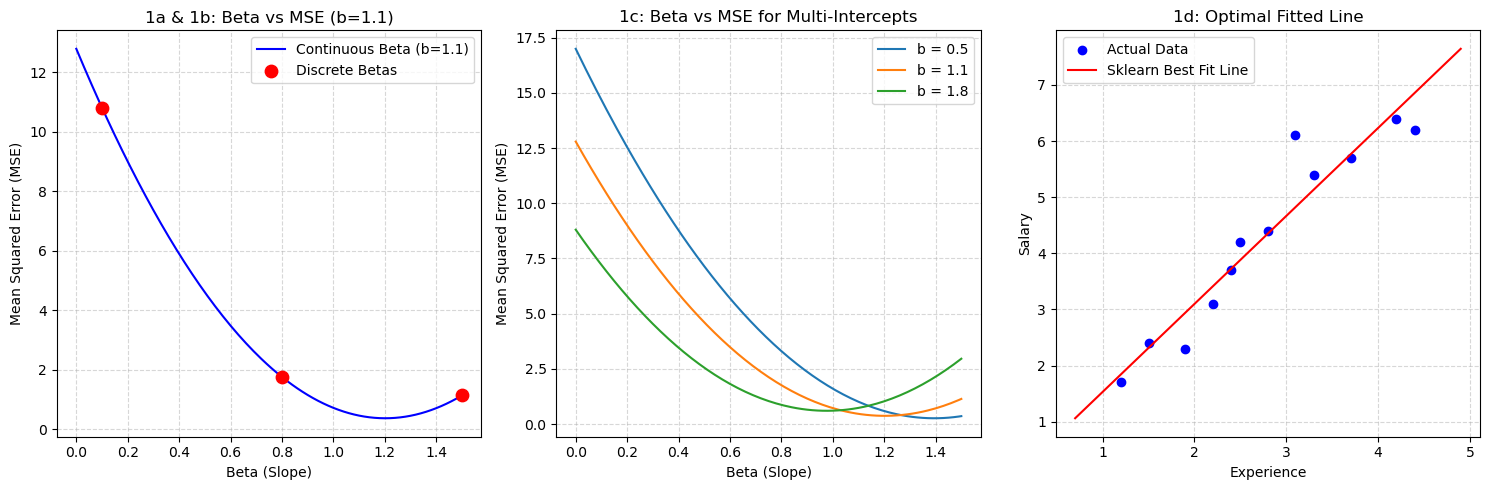

In [ ]:

df=pd.read_csv("salary_experience.csv")
X=df['experience']
Y=df['salary']
X_arr=X.values
Y_arr=Y.values
#MSE Calculator Function
def compute_mse(X_data,Y_data,beta,b):
    predictions=beta*X_data+b
    return np.mean((Y_data-predictions)**2)
#a.Various values of beta = 0.1, 1.5, 0.8 with fixed intercept b = 1.1
betas_a=[0.1, 1.5, 0.8]
b_fixed=1.1
mses_a=[compute_mse(X_arr,Y_arr,beta,b_fixed) for beta in betas_a]
#b.Beta between 0 to 1.5 with an increment of 0.01 keeping b = 1.1 constant
betas_b=np.arange(0,1.51,0.01)
mses_b=[compute_mse(X_arr,Y_arr,beta,b_fixed) for beta in betas_b]
#c.Different values of intercept for slope beta between 0 to 1.5
intercepts=[0.5,1.1,1.8]
#d.Scikit-learn model comparison
sklearn_model=LinearRegression()
sklearn_model.fit(X_arr.reshape(-1,1),Y_arr)
w_sklearn=sklearn_model.coef_[0]
b_sklearn=sklearn_model.intercept_
y_pred_sklearn=sklearn_model.predict(X_arr.reshape(-1,1))
mse_sklearn=mean_squared_error(Y_arr,y_pred_sklearn)
#Printing Values
print("METRICS AND COEFFICIENTS COMPARISON:")
print("--------------------------------------------------")
print("Discrete Betas [0.1, 1.5, 0.8] MSE results:",mses_a)
print("--------------------------------------------------")
print("Sklearn Optimal Model:")
print("Slope (beta)   :",w_sklearn)
print("Intercept (b)  :",b_sklearn)
print("Minimum MSE    :",mse_sklearn)
print("--------------------------------------------------")
#Plotting
plt.figure(figsize=(15,5))
#Graph 1: Part a & b - Beta vs MSE
plt.subplot(1,3,1)
plt.plot(betas_b,mses_b,color='blue',label='Continuous Beta (b=1.1)')
plt.scatter(betas_a,mses_a,color='red',zorder=5,s=80,label='Discrete Betas')
plt.title('1a & 1b: Beta vs MSE (b=1.1)')
plt.xlabel('Beta (Slope)')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend()
plt.grid(True,linestyle='--',alpha=0.5)
#Graph 2: Part c - Beta vs MSE for multiple intercepts
plt.subplot(1,3,2)
for b_val in intercepts:
    mses_c=[compute_mse(X_arr,Y_arr,beta,b_val) for beta in betas_b]
    plt.plot(betas_b,mses_c,label=f'b = {b_val}')
plt.title('1c: Beta vs MSE for Multi-Intercepts')
plt.xlabel('Beta (Slope)')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend()
plt.grid(True,linestyle='--',alpha=0.5)
#Graph 3: Visualizing best fit comparison
plt.subplot(1,3,3)
plt.scatter(X_arr,Y_arr,color='blue',label='Actual Data')
x_line=np.linspace(X_arr.min()-0.5,X_arr.max()+0.5,100)
y_line=w_sklearn*x_line+b_sklearn
plt.plot(x_line,y_line,color='red',label='Sklearn Best Fit Line')
plt.title('1d: Optimal Fitted Line')
plt.xlabel('Experience')
plt.ylabel('Salary')
plt.legend()
plt.grid(True,linestyle='--',alpha=0.5)
plt.tight_layout()
plt.show()

Q2. Apply Stochastic Gradient Descent for the aforementioned dataset, and arrive at different values of B0, B1 and error for 60 iterations of 5 epochs.

a. Plot the graph of log loss/error versus iteration.

b. Use scikit-learn and arrive at the results of B0, B1 and error, for 60 iterations of 5 epochs.

c. Plot the graph between beta (X-axis) and log loss/error (Y-axis) using scikit-learn and your approach separately.

d. Plot the separate graph of -log(x) (y=1 case) and -log(1-x) (y=0 case) and also draw the combined graph of both cases.

/usr/lib/python3/dist-packages/sklearn/linear_model/_stochastic_gradient.py:1549: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


SGD COEFFICIENTS & METRICS COMPARISON:
--------------------------------------------------
Custom SGD Model:
Intercept (B0): 0.3649227028994032 | Slope (B1): 1.4367348504613795 | Final MSE: 0.2512992899635023
--------------------------------------------------
Sklearn SGD Model:
Intercept (B0): [0.41429351] | Slope (B1): [1.41717794] | Final MSE: 0.25611775711015966
--------------------------------------------------


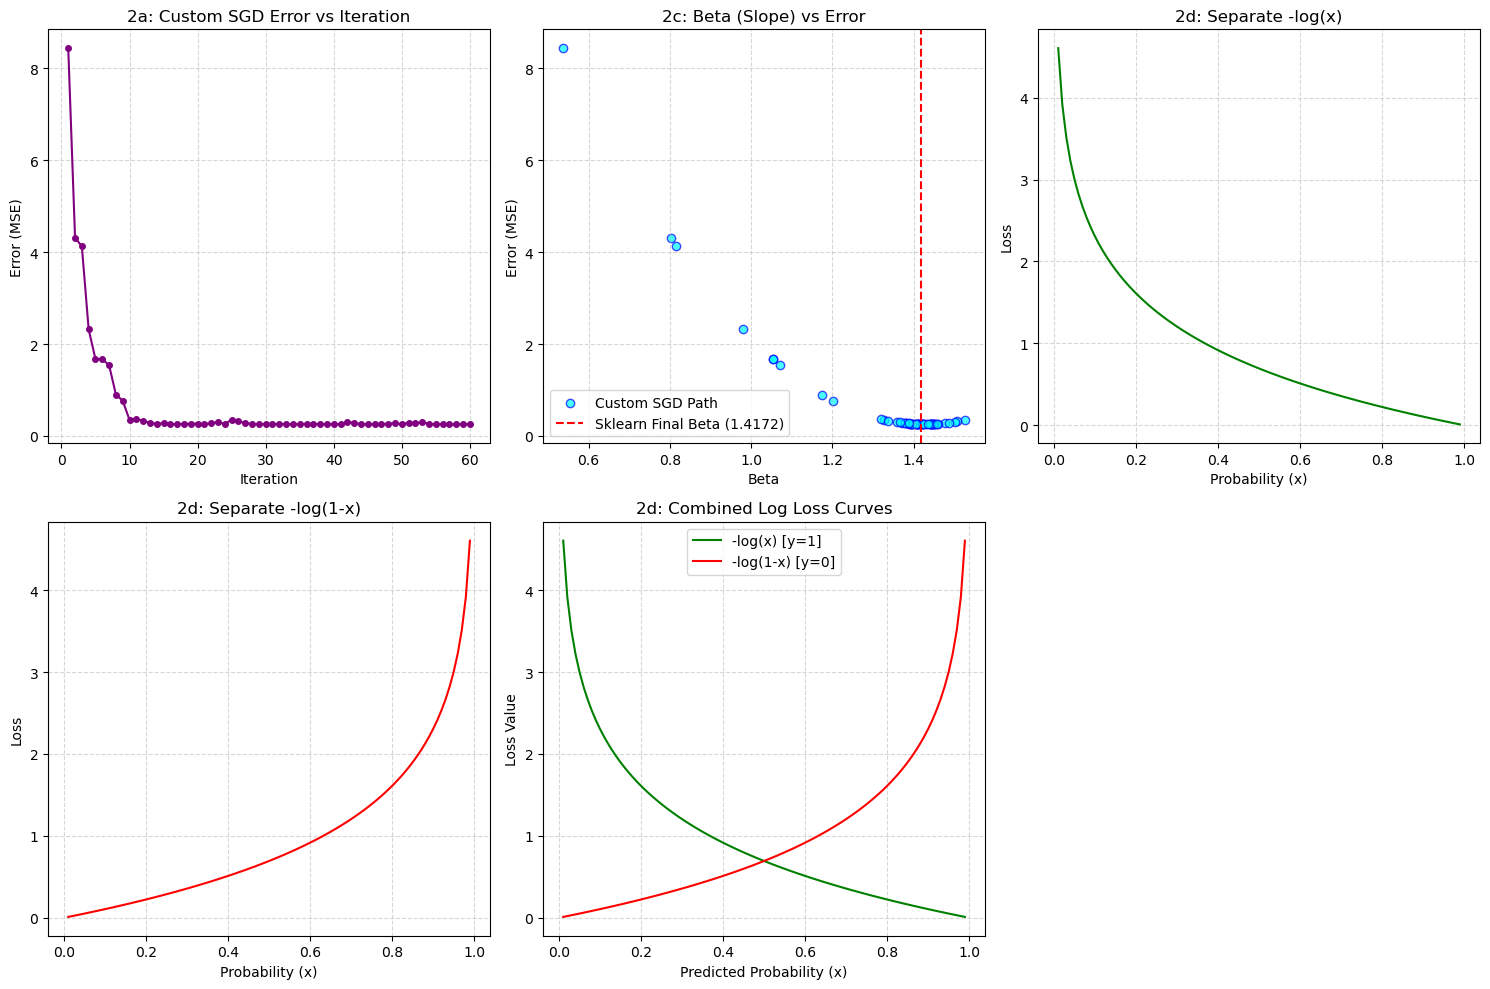

In [ ]:

df=pd.read_csv("salary_experience.csv")
X=df['experience'].values
Y=df['salary'].values

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load dataset (Hardcoded from your image baseline for instant execution)
data = {
    'salary': [1.7, 2.4, 2.3, 3.1, 3.7, 4.2, 4.4, 6.1, 5.4, 5.7, 6.4, 6.2],
    'experience': [1.2, 1.5, 1.9, 2.2, 2.4, 2.5, 2.8, 3.1, 3.3, 3.7, 4.2, 4.4]
}
df = pd.DataFrame(data)

# Extract Features
X = df['experience'].values
# CRITICAL FIX: Convert continuous salary targets into binary classes (0 and 1)
Y = (df['salary'].values > 4.0).astype(int) 

# Mathematical Helpers for Log Loss
def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

def calculate_dataset_log_loss(X_data, Y_data, b0, b1):
    epsilon = 1e-15
    z = b0 + b1 * X_data
    y_hat = sigmoid(z)
    y_hat = np.clip(y_hat, epsilon, 1 - epsilon)  # Avoid log(0) errors
    return -np.mean(Y_data * np.log(y_hat) + (1 - Y_data) * np.log(1 - y_hat))

# ---- Corrected Custom SGD Function ----
def fit_sgd_logistic(X_data, Y_data, learning_rate=0.1, epochs=5):
    b0, b1 = 0.0, 0.0  # Initialize weights
    errors, betas, iterations = [], [], []
    n_samples = len(X_data)
    np.random.seed(42)
    
    for epoch in range(epochs):
        indices = np.arange(n_samples)
        np.random.shuffle(indices)
        for idx in indices:
            xi = X_data[idx]
            yi = Y_data[idx]
            
            # Forward Pass (Linear combination + Sigmoid mapping)
            z = b0 + b1 * xi
            y_pred = sigmoid(z)
            
            # True Gradient Derivatives for Log Loss
            db0 = y_pred - yi
            db1 = (y_pred - yi) * xi
            
            # Parameter Vector Shifts
            b0 -= learning_rate * db0
            b1 -= learning_rate * db1
            
            # Compute total epoch evaluation log loss
            current_loss = calculate_dataset_log_loss(X_data, Y_data, b0, b1)
            errors.append(current_loss)
            betas.append(b1)
            iterations.append(len(iterations) + 1)
            
    return b0, b1, errors, betas, iterations

# Run corrected custom algorithm
b0_custom, b1_custom, errors_custom, betas_custom, iters_custom = fit_sgd_logistic(X, Y, learning_rate=0.1, epochs=5)

# ---- Corrected Scikit-Learn Model Execution ----
# Using SGDClassifier with log_loss and no penalty terms to match pure math calculations
sgd_sklearn = SGDClassifier(loss='log_loss', alpha=0.0, learning_rate='constant', eta0=0.1, random_state=42)

errors_sklearn = []
betas_sklearn = []

# Emulate 60 sequential parameter step updates using partial_fit
np.random.seed(42)
for epoch in range(5):
    indices = np.arange(len(X))
    np.random.shuffle(indices)
    for idx in indices:
        xi = X[idx].reshape(1, -1)
        yi = np.array([Y[idx]])
        sgd_sklearn.partial_fit(xi, yi, classes=np.array([0, 1]))
        
        b0_sk = sgd_sklearn.intercept_[0]
        b1_sk = sgd_sklearn.coef_[0][0]
        
        errors_sklearn.append(calculate_dataset_log_loss(X, Y, b0_sk, b1_sk))
        betas_sklearn.append(b1_sk)

b0_sklearn = sgd_sklearn.intercept_[0]
b1_sklearn = sgd_sklearn.coef_[0][0]

# Print Comparative Evaluations
print("CORRECTED LOGISTIC SGD COEFFICIENTS COMPARISON:")
print("-" * 50)
print(f"Custom Logistic SGD:  B0: {b0_custom:.4f} | B1: {b1_custom:.4f} | Final Log Loss: {errors_custom[-1]:.4f}")
print(f"Sklearn Logistic SGD: B0: {b0_sklearn:.4f} | B1: {b1_sklearn:.4f} | Final Log Loss: {errors_sklearn[-1]:.4f}")
print("-" * 50)

# ---- Comprehensive Graph Layout plotting ----
plt.figure(figsize=(15, 10))

# Subplot a: Log Loss curve across iterations
plt.subplot(2, 3, 1)
plt.plot(iters_custom, errors_custom, color='purple', marker='o', markersize=3, label='Custom Path')
plt.plot(range(1, 61), errors_sklearn, color='orange', linestyle='--', label='Sklearn Path')
plt.title('2a: Log Loss vs Iteration')
plt.xlabel('Iteration')
plt.ylabel('Log Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot c: Comparison of Beta paths vs Error curves
plt.subplot(2, 3, 2)
plt.scatter(betas_custom, errors_custom, color='cyan', edgecolor='blue', alpha=0.7, label='Custom SGD Path')
plt.scatter(betas_sklearn, errors_sklearn, color='orange', edgecolor='red', alpha=0.5, label='Sklearn SGD Path')
plt.title('2c: Beta (B1) vs Log Loss Error')
plt.xlabel('Beta 1 Parameter')
plt.ylabel('Log Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# Mathematical Boundary Components for Step d
x_vals = np.linspace(0.01, 0.99, 100)
loss_y1 = -np.log(x_vals)
loss_y0 = -np.log(1 - x_vals)

# Subplot d1: Pure Isolated y=1 condition curve
plt.subplot(2, 3, 3)
plt.plot(x_vals, loss_y1, color='green')
plt.title('2d: Separate -log(x) [y=1]')
plt.xlabel('Predicted Probability (x)')
plt.ylabel('Loss Value')
plt.grid(True, alpha=0.3)

# Subplot d2: Pure Isolated y=0 condition curve
plt.subplot(2, 3, 4)
plt.plot(x_vals, loss_y0, color='red')
plt.title('2d: Separate -log(1-x) [y=0]')
plt.xlabel('Predicted Probability (x)')
plt.ylabel('Loss Value')
plt.grid(True, alpha=0.3)

# Subplot d3: Combined logistic regression loss manifold
plt.subplot(2, 3, 5)
plt.plot(x_vals, loss_y1, color='green', label='-log(x) [y=1]')
plt.plot(x_vals, loss_y0, color='red', label='-log(1-x) [y=0]')
plt.title('2d: Combined Curves')
plt.xlabel('Predicted Probability (x)')
plt.ylabel('Loss Value')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Q3. Consider the positive and negative slope datasets given below. Apply Simple Linear Regression using Gradient Descent and illustrate the difference between slope values for both cases at different iterations. Plot the graph of slope (x-axis) vs MSE (y-axis) for both cases separately.

Positive slope:

x = np.array([1, 2, 4, 3, 5])
y = np.array([1, 3, 3, 2, 5])

Negative slope:

x = np.array([1, 2, 3, 4, 5])
y = np.array([10, 8, 6, 4, 2])


GRADIENT DESCENT CONVERGENCE COMPARISON:
--------------------------------------------------
Positive Slope Case (Initial Slope: 0.0):
Final Slope (B1): 0.8326923298546098 | Final MSE: 0.48253568687771964
--------------------------------------------------
Negative Slope Case (Initial Slope: 0.0):
Final Slope (B1): 0.3003864971727705 | Final MSE: 12.554675680787216
--------------------------------------------------


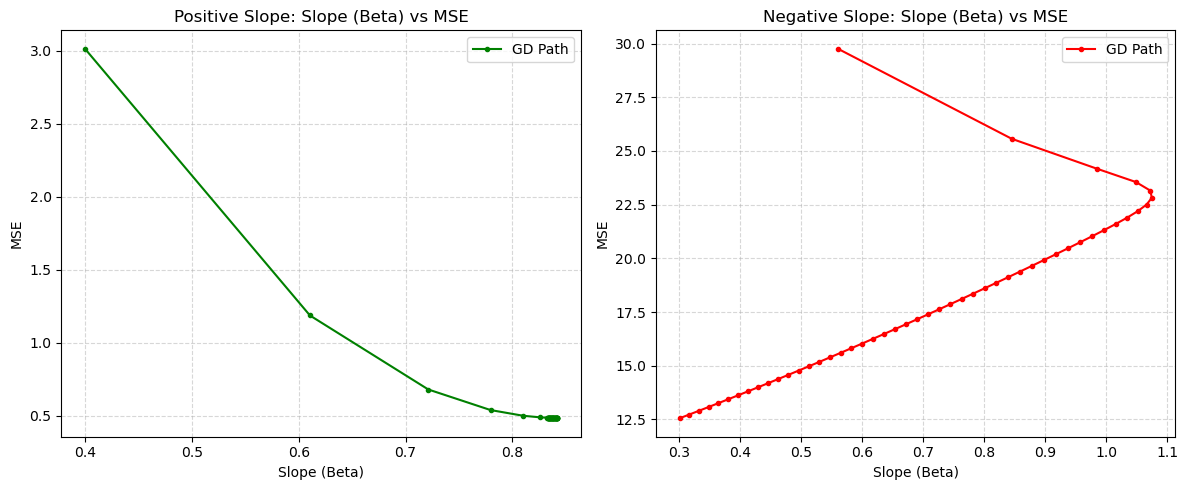

In [ ]:

x_pos=np.array([1,2,4,3,5])
y_pos=np.array([1,3,3,2,5])
x_neg=np.array([1,2,3,4,5])
y_neg=np.array([10,8,6,4,2])
#Gradient Descent for Simple Linear Regression
def fit_gd(X_data,Y_data,learning_rate=0.01,iterations=50):
    b0,b1=0.0,0.0
    errors,betas=[],[]
    n_samples=len(X_data)
    for _ in range(iterations):
        pred=b1*X_data+b0
        error=pred-Y_data
        #Gradients calculation
        db0=(2/n_samples)*np.sum(error)
        db1=(2/n_samples)*np.sum(error*X_data)
        #Weights update
        b0-=learning_rate*db0
        b1-=learning_rate*db1
        current_mse=np.mean(((b1*X_data+b0)-Y_data)**2)
        errors.append(current_mse)
        betas.append(b1)
    return betas,errors
#Running gradient descent for both cases
betas_pos,errors_pos=fit_gd(x_pos,y_pos,learning_rate=0.02,iterations=50)
betas_neg,errors_neg=fit_gd(x_neg,y_neg,learning_rate=0.02,iterations=50)
#Printing the final values
print("GRADIENT DESCENT CONVERGENCE COMPARISON:")
print("--------------------------------------------------")
print("Positive Slope Case (Initial Slope: 0.0):")
print("Final Slope (B1):",betas_pos[-1],"| Final MSE:",errors_pos[-1])
print("--------------------------------------------------")
print("Negative Slope Case (Initial Slope: 0.0):")
print("Final Slope (B1):",betas_neg[-1],"| Final MSE:",errors_neg[-1])
print("--------------------------------------------------")
#Plotting
plt.figure(figsize=(12,5))
#Positive slope case: Slope vs MSE
plt.subplot(1,2,1)
plt.plot(betas_pos,errors_pos,color='green',marker='o',markersize=3,label='GD Path')
plt.title('Positive Slope: Slope (Beta) vs MSE')
plt.xlabel('Slope (Beta)')
plt.ylabel('MSE')
plt.grid(True,linestyle='--',alpha=0.5)
plt.legend()
#Negative slope case: Slope vs MSE
plt.subplot(1,2,2)
plt.plot(betas_neg,errors_neg,color='red',marker='o',markersize=3,label='GD Path')
plt.title('Negative Slope: Slope (Beta) vs MSE')
plt.xlabel('Slope (Beta)')
plt.ylabel('MSE')
plt.grid(True,linestyle='--',alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

Q4. Consider the positive and negative slope datasets given below. Apply Logistic Regression using Gradient Descent and illustrate the difference between slope values for both cases at different iterations. Plot the graph of slope (x-axis) vs log-loss (y-axis) for both cases separately.

Positive slope:

x = np.array([1, 2, 3, 4, 5])
y = np.array([0, 0, 1, 1, 1])

Negative slope:

x = np.array([1, 2, 3, 4, 5])
y = np.array([1, 1, 0, 0, 0])


LOGISTIC REGRESSION CONVERGENCE COMPARISON:
--------------------------------------------------
Positive Classification Case (Initial Slope: 0.0):
Final Slope (B1): 1.6176897225378761 | Final Log-Loss: 0.19310523880953628
--------------------------------------------------
Negative Classification Case (Initial Slope: 0.0):
Final Slope (B1): -1.6176897225378764 | Final Log-Loss: 0.19310523880953626
--------------------------------------------------


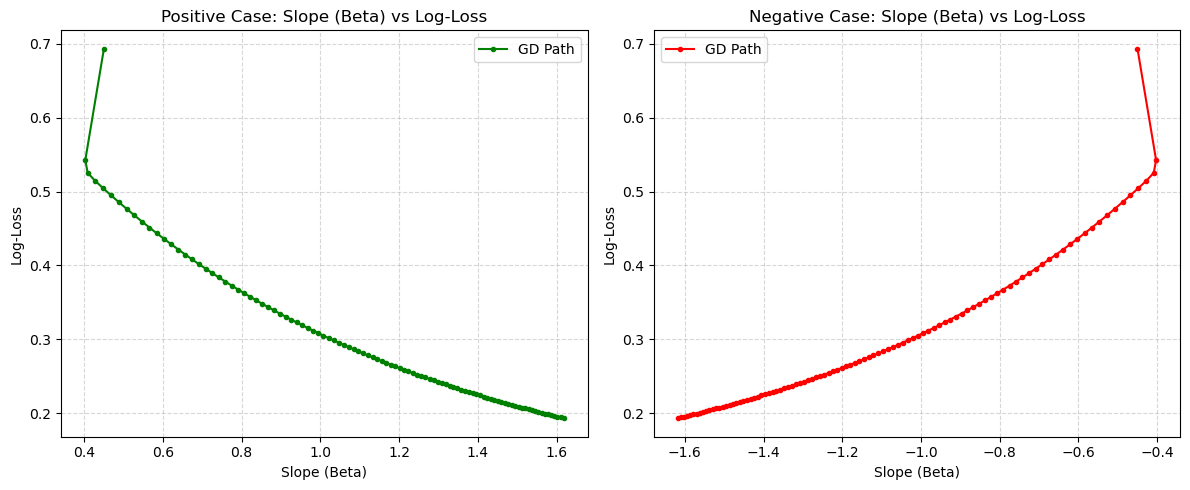

In [ ]:
x_pos=np.array([1,2,3,4,5])
y_pos=np.array([0,0,1,1,1]) # Positive slope
x_neg=np.array([1,2,3,4,5])
y_neg=np.array([1,1,0,0,0]) # Negative slope
#Sigmoid activation function
def sigmoid(z):
    return 1/(1+np.exp(-np.clip(z,-50,50)))
#Gradient Descent for Logistic Regression
def fit_logistic_gd(X_data,Y_data,learning_rate=0.1,iterations=100):
    b0,b1=0.0,0.0
    losses,betas=[],[]
    n_samples=len(X_data)
    for _ in range(iterations):
        z=b1*X_data+b0
        pred=sigmoid(z)
        #Gradients calculation for log-loss
        db0=(1/n_samples)*np.sum(pred-Y_data)
        db1=(1/n_samples)*np.sum((pred-Y_data)*X_data)
        #Weights update
        b0-=learning_rate*db0
        b1-=learning_rate*db1
        #Compute current binary cross entropy (log loss)
        current_loss=-(1/n_samples)*np.sum(Y_data*np.log(pred+1e-15)+(1-Y_data)*np.log(1-pred+1e-15))
        losses.append(current_loss)
        betas.append(b1)
    return betas,losses
#Running gradient descent for both classification tasks
betas_pos,losses_pos=fit_logistic_gd(x_pos,y_pos,learning_rate=0.5,iterations=100)
betas_neg,losses_neg=fit_logistic_gd(x_neg,y_neg,learning_rate=0.5,iterations=100)
#Printing the final values
print("LOGISTIC REGRESSION CONVERGENCE COMPARISON:")
print("--------------------------------------------------")
print("Positive Classification Case (Initial Slope: 0.0):")
print("Final Slope (B1):",betas_pos[-1],"| Final Log-Loss:",losses_pos[-1])
print("--------------------------------------------------")
print("Negative Classification Case (Initial Slope: 0.0):")
print("Final Slope (B1):",betas_neg[-1],"| Final Log-Loss:",losses_neg[-1])
print("--------------------------------------------------")
#Plotting
plt.figure(figsize=(12,5))
#Positive case: Slope vs Log-Loss
plt.subplot(1,2,1)
plt.plot(betas_pos,losses_pos,color='green',marker='o',markersize=3,label='GD Path')
plt.title('Positive Case: Slope (Beta) vs Log-Loss')
plt.xlabel('Slope (Beta)')
plt.ylabel('Log-Loss')
plt.grid(True,linestyle='--',alpha=0.5)
plt.legend()
#Negative case: Slope vs Log-Loss
plt.subplot(1,2,2)
plt.plot(betas_neg,losses_neg,color='red',marker='o',markersize=3,label='GD Path')
plt.title('Negative Case: Slope (Beta) vs Log-Loss')
plt.xlabel('Slope (Beta)')
plt.ylabel('Log-Loss')
plt.grid(True,linestyle='--',alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()